 # ASM06 — Gold & Silver Prices: Dự báo giá vàng bằng RNN đơn tầng (Keras)

 **Môn học:** HTTM — Assignment 06: *Recurrent Neural Network — dữ liệu chuỗi thời gian*

 **Dataset:** [Gold & Silver Prices](https://www.kaggle.com/datasets/lbronchal/gold-and-silver-prices-dataset)
 (Kaggle, lbronchal) — giá vàng & bạc USD/oz ngày 1968-01-02 → 2021-04-07.

 Đọc nhanh bảng thống kê lợi suất dưới đây: **std của bạc lớn hơn vàng** (bạc biến động mạnh
 hơn), **kurtosis dương lớn** (đuôi dày — ngày biến động cực đoan), **tương quan ~0.7**
 (2 kim loại cùng chiều nhưng không hoàn hảo — lý do dùng cả 2 làm đặc trưng đầu vào).

 Notebook **02/02** — lặp lại **đúng quy trình** của notebook 01 (PyTorch) bằng Keras/TensorFlow
 để so sánh chéo 2 framework trên cùng dữ liệu, cùng seed, cùng cấu hình — **bao gồm nâng cấp
 dự báo Δ phần dư (delta residual)** đã giúp notebook 01 thắng baseline naive:

 | Mục | Nội dung |
 |---|---|
 | §1 | EDA **rút gọn** (1 hình tổng hợp + bảng thống kê) — chi tiết 4 hình EDA & phân tích regime change xem **notebook 01** |
 | §2 | Preprocess: chia **chronological 70/15/15** + MinMax fit train + cửa sổ trượt L=30, **nhãn Δ phần dư** (z[i]−z[i−1]) clip ±3σ |
 | §3 | Model `SimpleRNN(128)` + `Dense(1)` — bảng tham số & ánh xạ sang công thức Elman RNN |
 | §4 | Train MSE + Adam, batch 64, ≤30 epochs, EarlyStopping (patience 4, restore best) |
 | §5 | Đánh giá TEST scale gốc + **bảng so sánh: PyTorch RNN / Keras RNN / Naive / 2 bản mức giá (trước nâng cấp)** |
 | §6 | Trực quan hoá: dự báo test (zoom 200 ngày), dự báo đệ quy 30 ngày, scatter y=x |
 | §7 | Lưu `metals_rnn_keras.keras` + `metals_keras_meta.json` |

 > **Quy ước ASM06:** mọi hàm/lớp định nghĩa trong notebook đều có **ô markdown tiếng Việt đặt trước**
 > (công thức + vai trò + input/output). Notebook chạy top-to-bottom không cell lỗi.

 > **Nâng cấp Δ (delta residual):** nhãn đổi từ *mức giá* scaled sang **Δ phần dư** giữa 2 ngày
> liên tiếp + guard clip ±3σ(Δ train) — cùng kỹ thuật notebook 01 & notebook AMZN 03/04.

In [1]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")   # giới hạn thread BLAS
os.environ.setdefault("OMP_NUM_THREADS", "4")
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_SEED = 42
tf.keras.utils.set_random_seed(RANDOM_SEED)          # seed cho numpy/tf/tf.random

DATA = pathlib.Path("../data")                # goldsilver/data (so với thư mục notebook/)
FIG = pathlib.Path("../../figures")           # assignment06/figures
MODEL = pathlib.Path("../model")              # goldsilver/model
FIG.mkdir(exist_ok=True, parents=True)
MODEL.mkdir(exist_ok=True, parents=True)
plt.rcParams["figure.dpi"] = 100

WINDOW_START = "2000-01-01"                   # cùng cửa sổ mô hình với notebook 01
L_WINDOW = 30                                 # cùng chiều dài cửa sổ trượt
print("ASM06/goldsilver (Keras) — RANDOM_SEED =", RANDOM_SEED,
      "| TF", tf.__version__, "| L =", L_WINDOW, "| cửa sổ mô hình từ", WINDOW_START)

ASM06/goldsilver (Keras) — RANDOM_SEED = 42 | TF 2.21.0 | L = 30 | cửa sổ mô hình từ 2000-01-01


 ---
 ## §1. EDA rút gọn (chi tiết ở notebook 01)

 Notebook 01 đã phân tích đầy đủ: **regime change 1971** (vàng neo ~35 USD dưới Bretton Woods,
 NaN 141 ngày đầu; Nixon shock 15-08-1971 → tha nổi), spike bạc 1980, lợi suất đuôi dày,
 tương quan vàng–bạc ~0.7 không ổn định — vì vậy **cửa sổ mô hình = 2000-01-01+** (~5.332 ngày
 ≈ 21 năm, đủ cho 3 split, đồng nhất chế độ giá tự do). 4 hình EDA đầy đủ:
 `metals-01-history.png`, `metals-02-returns.png`, `metals-03-correlation.png`,
 `metals-04-monthly.png` (xem notebook 01).

 **Hàm `load_metals`** — vai trò: đọc 2 CSV → parse `date` → inner merge theo date → dropna
 → DataFrame index thời gian 2 cột `gold`, `silver` (13.300 ngày, 1968-04-01 → 2021-04-07).
 - **Input:** đường dẫn thư mục data — **Output:** DataFrame (13.300 × 2).

In [2]:
def load_metals(data_dir):
    """Đọc 2 CSV giá vàng/bạc → inner merge theo date + dropna → DataFrame index thời gian."""
    gold = pd.read_csv(data_dir / "gold_price.csv", parse_dates=["date"])
    silver = pd.read_csv(data_dir / "silver_price.csv", parse_dates=["date"])
    df = gold.merge(silver, on="date", how="inner", suffixes=("_gold", "_silver"))
    df = df.dropna().set_index("date").sort_index()
    return df.rename(columns={"price_gold": "gold", "price_silver": "silver"})


metals = load_metals(DATA)
model_df = metals.loc[metals.index >= WINDOW_START].copy()
returns = model_df / model_df.shift(1) - 1
stats_tab = pd.DataFrame({
    "mean": returns.mean(), "std": returns.std(), "skew": returns.skew(),
    "kurtosis": returns.kurt(), "r_vang_bac": [returns.gold.corr(returns.silver)] * 2,
}, index=["gold", "silver"])
print("Cửa sổ mô hình 2000+: %d ngày | %s → %s" % (len(model_df), model_df.index[0].date(),
                                                   model_df.index[-1].date()))
print("Giá vàng [%.2f, %.2f] | giá bạc [%.2f, %.2f] USD/oz"
      % (model_df.gold.min(), model_df.gold.max(), model_df.silver.min(), model_df.silver.max()))
print("\nThống kê lợi suất ngày (cửa sổ 2000+):")
print(stats_tab.round(5).to_string())

Cửa sổ mô hình 2000+: 5332 ngày | 2000-01-04 → 2021-04-07
Giá vàng [255.95, 2067.15] | giá bạc [4.07, 48.70] USD/oz

Thống kê lợi suất ngày (cửa sổ 2000+):
           mean      std     skew  kurtosis  r_vang_bac
gold    0.00040  0.01095 -0.13932   5.32579     0.56552
silver  0.00049  0.02013 -0.23155  10.54325     0.56552


 **Hình `metals-10-keras-eda.png`** — 1 hình tổng hợp 2 panel: (trái) lịch sử giá vàng–bạc
 log-scale 1968–2021 với vùng cửa sổ mô hình 2000+ và mốc Nixon shock 1971;
 (phải) phân phối lợi suất ngày 2 kim loại trong cửa sổ 2000+ (đuôi dày).

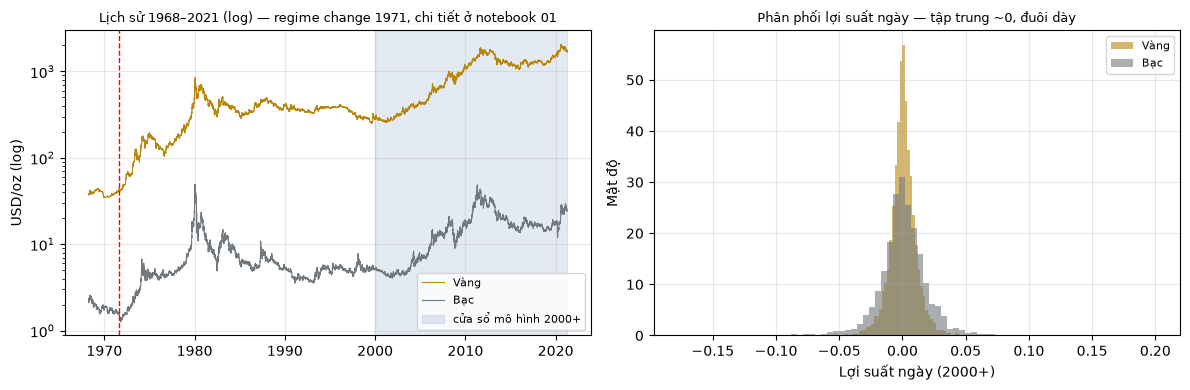

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nixon = pd.Timestamp("1971-08-15")
axes[0].plot(metals.index, metals.gold, color="#B8860B", lw=0.8, label="Vàng")
axes[0].plot(metals.index, metals.silver, color="#71797E", lw=0.8, label="Bạc")
axes[0].set_yscale("log")
axes[0].axvline(nixon, color="red", ls="--", lw=1)
axes[0].axvspan(pd.Timestamp(WINDOW_START), metals.index.max(), color="#4C72B0", alpha=0.15,
                label="cửa sổ mô hình 2000+")
axes[0].set_ylabel("USD/oz (log)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_title("Lịch sử 1968–2021 (log) — regime change 1971, chi tiết ở notebook 01", fontsize=9)
for col, color, name in [("gold", "#B8860B", "Vàng"), ("silver", "#71797E", "Bạc")]:
    axes[1].hist(returns[col].dropna(), bins=80, density=True, alpha=0.6,
                 color=color, label=name)
axes[1].set_xlabel("Lợi suất ngày (2000+)"); axes[1].set_ylabel("Mật độ")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_title("Phân phối lợi suất ngày — tập trung ~0, đuôi dày", fontsize=9)
plt.tight_layout()
plt.savefig(FIG / "metals-10-keras-eda.png", bbox_inches="tight")
plt.show()

 ### §1.1 Đối chứng regime change theo thập kỷ

 Bảng giá trung bình theo thập kỷ (toàn lịch sử 1968–2021) tái hiện phân tích của notebook 01:
 vàng trung bình **~35–40 USD trong thập kỷ 1970 trở về trước** (giai đoạn neo giá Bretton
 Woods, 141 ngày đầu không có giá) rồi tăng vọt sau 1971 — hai chế độ giá khác nhau nên
 **chỉ mô hình hoá cửa sổ 2000+** (nhất quán với notebook 01).

In [4]:
decade = metals.groupby((metals.index.year // 10) * 10)[["gold", "silver"]].mean()
decade.index = [f"{d}s" for d in decade.index]
print("Giá trung bình theo thập kỷ (USD/oz):")
print(decade.round(2).to_string())

Giá trung bình theo thập kỷ (USD/oz):
          gold  silver
1960s    40.56    1.98
1970s   132.36    4.19
1980s   418.29    8.97
1990s   350.95    4.85
2000s   522.30    8.74
2010s  1346.90   21.10
2020s  1774.11   21.68


 ---
 ## §2. Preprocess — giống hệt notebook 01 (để so sánh được)

 **Chia chronological 70/15/15, KHÔNG shuffle:** chuỗi thời gian có trật tự nhân quả — shuffle
 làm mẫu tương lai lọt vào train → **data leakage**, sai số test ảo thấp. Chia theo thời gian
 train (quá khứ) → val (điều chỉnh) → test (tương lai) mô phỏng đúng cách dùng thật.
 **MinMaxScaler fit TREN TRAIN** rồi transform val/test (val/test có thể vượt [0,1] vì vùng
 giá 2018–2021 cao hơn train — ánh xạ tuyến tính, không leakage thống kê).

 ### §2.1 Nhãn Δ phần dư (nâng cấp, giống notebook 01)

 Nhãn **không còn là mức giá scaled** mà là **Δ phần dư**:
 $\Delta_i = z_{i+L,\,0} - z_{i+L-1,\,0}$ (biến thiên giá vàng scaled giữa 2 ngày liên tiếp).
 Lý do chi tiết ở notebook 01 §2.2 — tóm tắt: mô hình mức giá bị "làm mượt" → dự báo trễ 1 ngày
 → RMSE ≈ $\sqrt{2}\times$naive (Keras chạy trước nâng cấp: RMSE 82,4 ≈ 5,3 × naive 15,5);
 Δ phân bố quanh 0, cùng lớp giá trị train/test, và **naive "mai = hôm nay" = Δ̂ 0** nên so
 sánh naive là công bằng nhất. Nhãn và dự báo Δ đều bị **guard clip ±3σ(Δ train)** (đuôi dày
 — lợi suất khủng hoảng; chống bão hoà ngoại suy).

 **Hàm `make_windows`** — vai trò: trượt cửa sổ $L=30$ trên ma trận đặc trưng $[\text{gold},
 \text{silver}]$ scaled: mẫu $i$ có $X_i \in \mathbb{R}^{30\times2}$, nhãn $y_i$ = **Δ vàng
 scaled** ngày $i+30$ (chưa clip — clip ở ô sau khi biết σ train).
 - **Input:** mảng scaled (n, 2) — **Output:** `X` (n−30, 30, 2) float32, `y` (n−30,) float32.

 **Chú ý inverse scale (dùng ở §5):** scaler được fit trên 2 cột nên khi chuyển giá về USD/oz
 phải tạo **mảng giả 2 cột** (cột bạc điền 0) rồi `inverse_transform` và lấy cột 0 — inverse
 trực tiếp mảng 1 cột sẽ sai chiều. Giá dự báo = inverse(vàng scaled hôm nay + Δ̂).
 Ngoài ra mỗi cửa sổ được tạo **trong từng split** (không trượt qua ranh giới) → không mẫu
 nào dùng dữ liệu tương lai của split khác.

In [5]:
def make_windows(features, L):
    """Cửa sổ trượt: X[i] = features[i:i+L], y[i] = Δ vàng scaled = z[i+L,0] − z[i+L−1,0]."""
    X, y = [], []
    for i in range(len(features) - L):
        X.append(features[i:i + L])
        y.append(features[i + L, 0] - features[i + L - 1, 0])   # Δ = giá mai − giá hôm nay (scaled)
    return (np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32))


n = len(model_df)
n_train, n_val = int(n * 0.70), int(n * 0.85)
train_df = model_df.iloc[:n_train]
val_df = model_df.iloc[n_train:n_val]
test_df = model_df.iloc[n_val:]

scaler = MinMaxScaler()
scaler.fit(train_df.values)                    # fit CHỈ trên train
train_s = scaler.transform(train_df.values)
val_s = scaler.transform(val_df.values)
test_s = scaler.transform(test_df.values)

X_train, y_train_raw = make_windows(train_s, L_WINDOW)
X_val, y_val_raw = make_windows(val_s, L_WINDOW)
X_test, y_test_raw = make_windows(test_s, L_WINDOW)

SIGMA_DELTA = float(np.std(y_train_raw))               # σ của Δ train (scaled) — TRƯỚC khi clip
DELTA_BOUND = 3.0 * SIGMA_DELTA                        # biên guard ±3σ
BOUND_USD = DELTA_BOUND * (scaler.data_max_[0] - scaler.data_min_[0])
y_train = np.clip(y_train_raw, -DELTA_BOUND, DELTA_BOUND).astype(np.float32)
y_val = np.clip(y_val_raw, -DELTA_BOUND, DELTA_BOUND).astype(np.float32)

print("Chia chronological 70/15/15 (không shuffle) — giống notebook 01:")
print("  train: %5d ngày → %d cửa sổ | %s → %s" % (n_train, len(X_train), train_df.index[0].date(), train_df.index[-1].date()))
print("  val  : %5d ngày → %d cửa sổ | %s → %s" % (n_val - n_train, len(X_val), val_df.index[0].date(), val_df.index[-1].date()))
print("  test : %5d ngày → %d cửa sổ | %s → %s" % (n - n_val, len(X_test), test_df.index[0].date(), test_df.index[-1].date()))
print("X_train %s | X_val %s | X_test %s | y = Δ vàng scaled (phần dư)"
      % (X_train.shape, X_val.shape, X_test.shape))
print("Guard Δ: σ(Δ train) = %.5f scaled → biên ±3σ = ±%.5f scaled ≈ ±%.2f USD/ngày (giống nb 01)"
      % (SIGMA_DELTA, DELTA_BOUND, BOUND_USD))
print("Nhãn bị clip về biên: train %d/%d | val %d/%d"
      % ((np.abs(y_train_raw) > DELTA_BOUND).sum(), len(y_train_raw),
         (np.abs(y_val_raw) > DELTA_BOUND).sum(), len(y_val_raw)))

Chia chronological 70/15/15 (không shuffle) — giống notebook 01:
  train:  3732 ngày → 3702 cửa sổ | 2000-01-04 → 2014-11-17
  val  :   800 ngày → 770 cửa sổ | 2014-11-18 → 2018-01-29
  test :   800 ngày → 770 cửa sổ | 2018-01-30 → 2021-04-07
X_train (3702, 30, 2) | X_val (770, 30, 2) | X_test (770, 30, 2) | y = Δ vàng scaled (phần dư)
Guard Δ: σ(Δ train) = 0.00719 scaled → biên ±3σ = ±0.02158 scaled ≈ ±35.38 USD/ngày (giống nb 01)
Nhãn bị clip về biên: train 74/3702 | val 4/770


 **Hình `metals-11-keras-split.png`** — giá vàng 2000+ với 3 vùng train/val/test (bản sao
 trực quan của bước chia, đảm bảo 2 notebook dùng cùng ranh giới split).

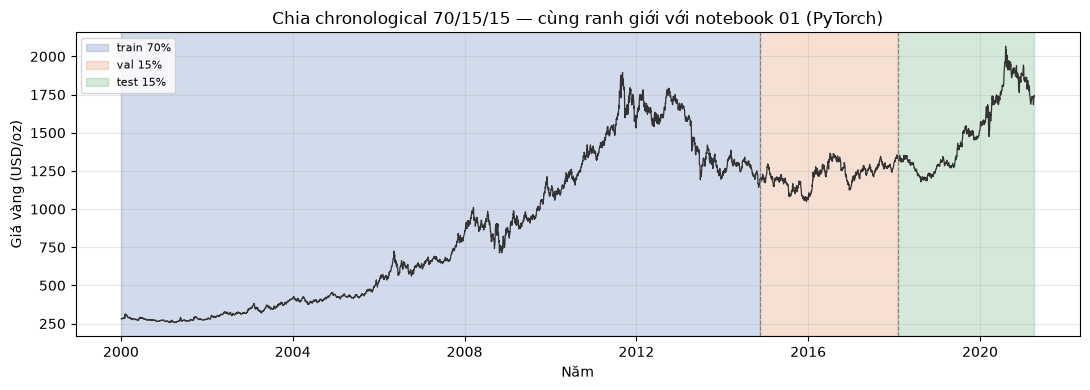

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(model_df.index, model_df.gold, color="#333333", lw=0.9)
bounds = [(train_df.index[0], train_df.index[-1], "#4C72B0", "train 70%"),
          (val_df.index[0], val_df.index[-1], "#DD8452", "val 15%"),
          (test_df.index[0], test_df.index[-1], "#55A868", "test 15%")]
for lo, hi, c, lab in bounds:
    ax.axvspan(lo, hi, color=c, alpha=0.25, label=lab)
for lo, _, _, _ in bounds[1:]:
    ax.axvline(lo, color="gray", ls="--", lw=0.8)
ax.set_ylabel("Giá vàng (USD/oz)"); ax.set_xlabel("Năm")
ax.set_title("Chia chronological 70/15/15 — cùng ranh giới với notebook 01 (PyTorch)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-11-keras-split.png", bbox_inches="tight")
plt.show()

 ---
 ## §3. Mô hình RNN đơn tầng (Keras)

 ### §3.1 Công thức Elman RNN (chuẩn dùng chung ASM06)

 Với chuỗi đầu vào $x_1,\dots,x_T$, mỗi $x_t \in \mathbb{R}^{2}$ = [gold, silver] scaled:

 $$\boxed{h_t = \tanh\big(W x_t + U h_{t-1} + b_h\big)}, \qquad
 W \in \mathbb{R}^{128\times 2},\ U \in \mathbb{R}^{128\times 128}$$

 $$\boxed{\hat{\Delta} = V h_T + b_y} \qquad V \in \mathbb{R}^{1\times 128}$$

 Đầu ra là **Δ phần dư** (§2.1); giá dự báo (scaled) = vàng scaled "hôm nay" $+ \hat{\Delta}$
 rồi inverse về USD/oz (§5).

 **Ánh xạ sang `layers.SimpleRNN(128)`:** `weights[0]` = $W$ (kernel, shape (2,128)),
 `weights[1]` = $U$ (recurrent, (128,128)), `weights[2]` = $b_h$ (bias, (128,)).
 `return_sequences=False` (mặc định) → tầng chỉ trả **$h_T$**; `Dense(1)` = $V, b_y$.

 **Khác biệt nhỏ so với PyTorch (nb 01):** Keras gộp bias thành **1 tensor (128,)**, còn
 `nn.RNN` tách `bias_ih + bias_hh` (128+128=256) — cùng hàm số, cách tham số hoá bias khác nhau
 (PyTorch tổng 17.025 vs Keras 16.897 tham số, chênh đúng 128).

 **Vì sao hidden 64 → 128?** cùng thí nghiệm đối chứng của notebook 01 (pipeline Δ, seed 42):
 hidden 128 cho RMSE thấp hơn và DirAcc rõ rệt hơn 50% — nâng cấp đồng bộ 2 framework.

 **Mô hình** — `Sequential([Input(30,2), SimpleRNN(128), Dense(1)])`, tương đương khai báo
 `SimpleRNN(128, input_shape=(30,2)) + Dense(1)`.

In [7]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(L_WINDOW, 2), name="input_30ngay_2feature"),
    tf.keras.layers.SimpleRNN(128, name="rnn_128"),
    tf.keras.layers.Dense(1, name="dense_out"),
], name="MetalsRNN_Keras")
model.summary()

Model: "MetalsRNN_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_128 (SimpleRNN)             │ (None, 128)            │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_out (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

 **Bảng tham số** — đọc trực tiếp từ `get_weights()` (đối chiếu công thức):

 | Thành phần | Tensor Keras | Shape | Số tham số |
 |---|---|---|---|
 | $W$ (input→hidden) | `rnn_128.weights[0]` (kernel) | 2×128 | 256 |
 | $U$ (hidden→hidden) | `rnn_128.weights[1]` (recurrent) | 128×128 | 16.384 |
 | $b_h$ | `rnn_128.weights[2]` (bias) | 128 | 128 |
 | $V$ (hidden→out) | `dense_out.kernel` | 128×1 | 128 |
 | $b_y$ | `dense_out.bias` | 1 | 1 |
 | **Tổng** | | | **16.897** |

In [8]:
rnn_W, rnn_U, rnn_b = model.get_layer("rnn_128").get_weights()
den_V, den_b = model.get_layer("dense_out").get_weights()
param_df = pd.DataFrame(
    [["rnn_128.kernel (W)", rnn_W.shape, rnn_W.size],
     ["rnn_128.recurrent (U)", rnn_U.shape, rnn_U.size],
     ["rnn_128.bias (b_h)", rnn_b.shape, rnn_b.size],
     ["dense_out.kernel (V)", den_V.shape, den_V.size],
     ["dense_out.bias (b_y)", den_b.shape, den_b.size]],
    columns=["Tensor", "Shape", "Số tham số"]).set_index("Tensor")
print(param_df.to_string())
print("TỔNG số tham số:", model.count_params())

                            Shape  Số tham số
Tensor                                       
rnn_128.kernel (W)       (2, 128)         256
rnn_128.recurrent (U)  (128, 128)       16384
rnn_128.bias (b_h)         (128,)         128
dense_out.kernel (V)     (128, 1)         128
dense_out.bias (b_y)         (1,)           1
TỔNG số tham số: 16897


 ### §3.3 Kiểm chứng ánh xạ trọng số — forward "tay" bằng NumPy

 **Hàm `manual_rnn_forward`** — vai trò: tự viết đúng công thức
 $h_t = \tanh(W x_t + U h_{t-1} + b_h)$, $\hat{\Delta} = V h_T + b_y$ bằng NumPy, dùng chính
 các trọng số vừa lấy từ `SimpleRNN` (kernel = $W$, recurrent = $U$, bias = $b_h$) — nếu ánh xạ
 đúng, kết quả phải trùng khớp đầu ra của tầng Keras (sai lệch ~1e-7 do độ chính xác float).
 - **Input:** 1 cửa sổ (30, 2), bộ trọng số — **Output:** Δ scaled dự báo (số thực).

In [9]:
def manual_rnn_forward(window, W, U, b_h, V, b_y):
    """Chạy công thức Elman RNN bằng NumPy: h_t = tanh(W x_t + U h_(t-1) + b_h); y = V h_T + b_y."""
    h = np.zeros(U.shape[0], dtype=np.float64)        # h_0 = 0
    for t in range(window.shape[0]):
        h = np.tanh(W.T @ window[t].astype(np.float64) + U.T @ h + b_h)
    return float((V.T @ h + b_y).item())          # .item() vì kết quả là mảng 1 phần tử


sample_idx = 0
keras_out = float(model.predict(X_test[sample_idx:sample_idx + 1], verbose=0)[0, 0])
manual_out = manual_rnn_forward(X_test[sample_idx], rnn_W, rnn_U, rnn_b, den_V, den_b)
print("Cửa sổ test #%d — Keras SimpleRNN: %.8f | forward NumPy: %.8f | chênh lệch: %.2e"
      % (sample_idx, keras_out, manual_out, abs(keras_out - manual_out)))
assert abs(keras_out - manual_out) < 1e-5, "Ánh xạ trọng số W/U/b không khớp!"
print("KHỚP — công thức h_t = tanh(W x_t + U h_(t-1) + b_h) đúng với weights[0..2] của SimpleRNN.")

Cửa sổ test #0 — Keras SimpleRNN: 0.02586232 | forward NumPy: 0.02586234 | chênh lệch: 2.14e-08
KHỚP — công thức h_t = tanh(W x_t + U h_(t-1) + b_h) đúng với weights[0..2] của SimpleRNN.


 ---
 ## §4. Huấn luyện — MSE + Adam, EarlyStopping patience 4

 `compile(optimizer=Adam(lr=1e-3), loss="mse")`; `fit` với `batch_size=64`, tối đa 30 epochs,
 `validation_data=(X_val, y_val)`, callback `EarlyStopping(monitor="val_loss", patience=4,
 restore_best_weights=True)` — ngữ nghĩa giống notebook 01: dừng khi val loss không cải thiện
 4 epochs liền và **nạp lại trọng số tốt nhất**. Loss là MSE trên **Δ scaled** (đã clip ±3σ).

 **Vì sao cần EarlyStopping?** RNN một tầng dễ quá hợp lệ trên chuỗi giá (memorise mặt bằng
 giá rồi dao động quanh đó); theo dõi **val loss** (dữ liệu mô hình chưa thấy) cho biết lúc
 nào bắt đầu quá hợp lệ — dừng sớm + restore best cho mô hình vừa đủ giữa underfit và
 overfit, đồng thời tiết kiệm thời gian train.

In [10]:
EPOCHS, BATCH, LR = 30, 64, 1e-3
es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4,
                                      restore_best_weights=True, verbose=1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR), loss="mse")
hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)
history = {"train_loss": [float(v) for v in hist.history["loss"]],
           "val_loss": [float(v) for v in hist.history["val_loss"]],
           "epochs_run": len(hist.history["loss"]),
           "best_epoch": int(np.argmin(hist.history["val_loss"]) + 1)}
print("Train xong %d epochs | best epoch (val) = %d | val MSE tốt nhất %.6f"
      % (history["epochs_run"], history["best_epoch"], min(history["val_loss"])))

Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 16.


Train xong 20 epochs | best epoch (val) = 16 | val MSE tốt nhất 0.000045


 **Hình `metals-12-keras-loss.png`** — 2 curve train/val loss (MSE trên Δ scaled) của Keras model.

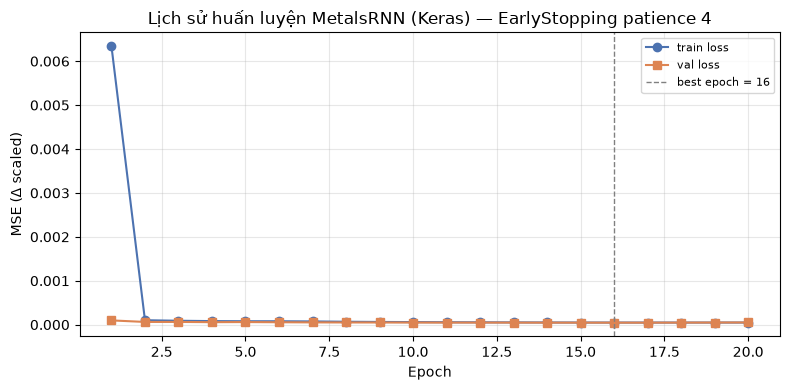

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ep = np.arange(1, history["epochs_run"] + 1)
ax.plot(ep, history["train_loss"], "o-", color="#4C72B0", label="train loss")
ax.plot(ep, history["val_loss"], "s-", color="#DD8452", label="val loss")
ax.axvline(history["best_epoch"], color="gray", ls="--", lw=1,
           label="best epoch = %d" % history["best_epoch"])
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (Δ scaled)")
ax.set_title("Lịch sử huấn luyện MetalsRNN (Keras) — EarlyStopping patience 4")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-12-keras-loss.png", bbox_inches="tight")
plt.show()

 ---
 ## §5. Đánh giá trên TEST (scale gốc) + so sánh các mô hình

 ### §5.1 Tái tạo giá từ Δ̂ + công thức chỉ số (USD/oz gốc)

 Mô hình xuất Δ̂ (scaled) → chặn guard ±3σ → **tái tạo giá** rồi mới tính chỉ số:
 $\hat{p}_i = \text{inverse\_gold}\big(z^{prev}_i + \hat{\Delta}_i\big)$ với $z^{prev}_i$ =
 vàng scaled "hôm nay" (ngày cuối cửa sổ $i$).

 $$\mathrm{RMSE} = \sqrt{\tfrac{1}{n}\sum (y_i - \hat{y}_i)^2}, \quad
 \mathrm{MAE} = \tfrac{1}{n}\sum |y_i - \hat{y}_i|, \quad
 \mathrm{MAPE} = \tfrac{100}{n}\sum \left|\tfrac{y_i - \hat{y}_i}{y_i}\right|$$

 $$R^2 = 1 - \tfrac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}, \quad
 \mathrm{DirAcc} = \tfrac{100}{n}\sum \mathbb{1}\big[\mathrm{sign}(\hat{y}_i - p^{prev}_i) = \mathrm{sign}(y_i - p^{prev}_i)\big]$$

 với $p^{prev}_i$ = giá vàng ngày cuối cửa sổ $i$ ("hôm nay"). **Baseline naive:** dự báo
 $\hat{y}_i = p^{prev}_i$ (ngày mai = hôm nay). **DirAcc của naive** theo quy ước **quán tính**
 (sửa định nghĩa cũ luôn ra 0): dự báo *chiều ngày mai = chiều hôm qua thực hiện*, tức
 $\mathrm{sign}(p^{prev}_i - p^{prev2}_i)$.

 **Hàm `inverse_gold`** — vai trò: scaled → USD/oz (đệm cột bạc = 0, inverse, lấy cột 0).
 **Hàm `evaluate_forecast`** — RMSE/MAE/MAPE/R². **Hàm `directional_accuracy`** — % đúng chiều.

In [12]:
def inverse_gold(y_scaled, scaler):
    """Inverse MinMax cho riêng cột vàng (đệm cột bạc = 0 rồi lấy cột 0)."""
    dummy = np.zeros((len(y_scaled), 2))
    dummy[:, 0] = y_scaled
    return scaler.inverse_transform(dummy)[:, 0]


def evaluate_forecast(y_true, y_pred):
    """RMSE, MAE, MAPE(%), R² trên đơn vị gốc."""
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mape": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
        "r2": float(r2_score(y_true, y_pred)),
    }


def directional_accuracy(y_prev, y_true, y_pred):
    """% ngày dự báo đúng chiều tăng/giảm so với giá hôm qua (bỏ mẫu đổi giá = 0)."""
    d_true = np.sign(y_true - y_prev)
    d_pred = np.sign(y_pred - y_prev)
    mask = (d_true != 0) & (d_pred != 0)
    return float(np.mean(d_true[mask] == d_pred[mask]) * 100)


delta_hat = model.predict(X_test, verbose=0).squeeze(-1)
delta_hat = np.clip(delta_hat, -DELTA_BOUND, DELTA_BOUND)     # guard ±3σ (no-op nếu mô hình khoẻ)
last_gold_scaled = test_s[L_WINDOW - 1:-1, 0]                 # vàng scaled "hôm nay" của từng cửa sổ
pred_real = inverse_gold(last_gold_scaled + delta_hat, scaler)   # giá dự báo = hôm nay + Δ̂
gold_test_real = test_df["gold"].values
y_true_real = gold_test_real[L_WINDOW:]
y_prev_real = gold_test_real[L_WINDOW - 1:-1]                 # giá "hôm nay" (= naive)
y_prev2_real = gold_test_real[L_WINDOW - 2:-2]                # giá "hôm qua" (naive quán tính)

m_model = evaluate_forecast(y_true_real, pred_real)
m_naive = evaluate_forecast(y_true_real, y_prev_real)
d_model = directional_accuracy(y_prev_real, y_true_real, pred_real)
naive_momentum = y_prev_real + (y_prev_real - y_prev2_real)   # naive quán tính: tiếp diễn chiều hôm qua
d_naive = directional_accuracy(y_prev_real, y_true_real, naive_momentum)
print("Keras RNN (Δ) — RMSE %.3f | MAE %.3f | MAPE %.3f%% | R² %.5f | DirAcc %.2f%%"
      % (m_model["rmse"], m_model["mae"], m_model["mape"], m_model["r2"], d_model))
print("Naive         — RMSE %.3f | MAE %.3f | MAPE %.3f%% | R² %.5f | DirAcc %.2f%% (quán tính)"
      % (m_naive["rmse"], m_naive["mae"], m_naive["mape"], m_naive["r2"], d_naive))
print("Guard Δ̂: max |Δ̂| = %.5f scaled vs biên ±%.5f → %s"
      % (np.abs(delta_hat).max(), DELTA_BOUND,
         "guard KHÔNG cắt gì (mô hình khoẻ)" if np.abs(delta_hat).max() < DELTA_BOUND
         else "guard cắt %d dự báo" % int((np.abs(delta_hat) >= DELTA_BOUND).sum())))

keras_vs_naive = pd.DataFrame(
    [["Keras RNN (Δ residual)", m_model["rmse"], m_model["mae"], m_model["mape"], m_model["r2"], d_model],
     ["Naive (mai = hôm)", m_naive["rmse"], m_naive["mae"], m_naive["mape"], m_naive["r2"], d_naive]],
    columns=["Mô hình", "RMSE (USD)", "MAE (USD)", "MAPE (%)", "R²", "DirAcc (%)"]).set_index("Mô hình")
print("\nKeras vs Naive trên TEST (%d mẫu):\n" % len(y_true_real))
print(keras_vs_naive.round(4).to_string())

Keras RNN (Δ) — RMSE 16.425 | MAE 10.729 | MAPE 0.678% | R² 0.99556 | DirAcc 51.76%
Naive         — RMSE 15.476 | MAE 10.207 | MAPE 0.646% | R² 0.99606 | DirAcc 51.30% (quán tính)
Guard Δ̂: max |Δ̂| = 0.01454 scaled vs biên ±0.02158 → guard KHÔNG cắt gì (mô hình khoẻ)

Keras vs Naive trên TEST (770 mẫu):

                        RMSE (USD)  MAE (USD)  MAPE (%)      R²  DirAcc (%)
Mô hình                                                                    
Keras RNN (Δ residual)     16.4246    10.7292    0.6780  0.9956     51.7555
Naive (mai = hôm)          15.4759    10.2071    0.6458  0.9961     51.3021


 **Kiểm tra ngưỡng MAPE (quy ước ASM06):** nếu MAPE test > 10% phải kiểm tra lại
 scaling/split hoặc tăng epochs / cửa sổ L. Ô dưới tự kiểm và kết luận.

In [13]:
print("MAPE test = %.3f%% %s 10%% → %s" % (
    m_model["mape"],
    ">" if m_model["mape"] > 10 else "≤",
    "CẦN ĐIỀU CHỈNH (scaling/split/epochs/L)."
    if m_model["mape"] > 10 else "đạt — không cần điều chỉnh; sai số chủ yếu đến từ tính gần random walk của giá."))

MAPE test = 0.678% ≤ 10% → đạt — không cần điều chỉnh; sai số chủ yếu đến từ tính gần random walk của giá.


 **Xem trước 5 mẫu test đầu tiên** — ngày dự báo, giá thật, dự báo Keras, dự báo naive:
 thấy trực quan cả 3 đường "bám" nhau — sai số từng ngày nhỏ so với mặt bằng giá ~1.500 USD.

In [14]:
preview = pd.DataFrame({
    "ngày": test_df.index[L_WINDOW:][:5].date,
    "thật (USD)": y_true_real[:5].round(2),
    "Keras (USD)": pred_real[:5].round(2),
    "naive (USD)": y_prev_real[:5].round(2),
})
print(preview.to_string(index=False))

      ngày  thật (USD)  Keras (USD)  naive (USD)
2018-03-13     1322.75      1318.12      1319.15
2018-03-14     1323.55      1324.88      1322.75
2018-03-15     1318.75      1326.11      1323.55
2018-03-16     1310.10      1321.26      1318.75
2018-03-19     1312.40      1310.73      1310.10


 ### §5.2 Bảng so sánh — PyTorch RNN (đọc meta nb 01) / Keras RNN / Naive / 2 bản mức giá cũ

 Notebook 01 lưu kết quả vào `../model/metals_pytorch_meta.json`; nếu file tồn tại thì nạp
 hàng "PyTorch RNN (Δ)" vào bảng (2 framework cùng dữ liệu + cùng quy trình → chênh lệch chỉ
 do cách khởi tạo/optimiser). Hai hàng cuối là kết quả **đã ghi nhận của chính 2 notebook này
 ở bản dự báo MỨC GIÁ scaled (trước nâng cấp Δ, hidden 64)** — để thấy rõ mức cải thiện.

In [15]:
PREV_LEVEL_PT = {"rmse": 33.3665, "mae": 23.4002, "mape": 1.4272, "r2": 0.98169, "dir": 45.8442}
PREV_LEVEL_KS = {"rmse": 82.3844, "mae": 67.6810, "mape": 4.1475, "r2": 0.88838, "dir": 47.5325}
rows = [["Keras RNN (Δ residual)", m_model["rmse"], m_model["mae"], m_model["mape"], m_model["r2"], d_model],
        ["Naive (mai = hôm)", m_naive["rmse"], m_naive["mae"], m_naive["mape"], m_naive["r2"], d_naive],
        ["PyTorch RNN — bản mức giá (cũ)", PREV_LEVEL_PT["rmse"], PREV_LEVEL_PT["mae"],
         PREV_LEVEL_PT["mape"], PREV_LEVEL_PT["r2"], PREV_LEVEL_PT["dir"]],
        ["Keras RNN — bản mức giá (cũ)", PREV_LEVEL_KS["rmse"], PREV_LEVEL_KS["mae"],
         PREV_LEVEL_KS["mape"], PREV_LEVEL_KS["r2"], PREV_LEVEL_KS["dir"]]]
pt_meta_path = MODEL / "metals_pytorch_meta.json"
if pt_meta_path.exists():
    pt = json.loads(pt_meta_path.read_text(encoding="utf-8"))
    rows.insert(0, ["PyTorch RNN (Δ, nb 01)", pt["metrics"]["rmse"], pt["metrics"]["mae"],
                    pt["metrics"]["mape"], pt["metrics"]["r2"], pt["metrics"]["directional_acc"]])
    src = "nguồn PyTorch: metals_pytorch_meta.json (nb 01 đã chạy bản Δ)"
else:
    src = "metals_pytorch_meta.json chưa có — chạy notebook 01 trước để thêm hàng PyTorch"
comp = pd.DataFrame(rows, columns=["Mô hình", "RMSE (USD)", "MAE (USD)", "MAPE (%)",
                                   "R²", "DirAcc (%)"]).set_index("Mô hình")
print("Bảng so sánh trên TEST (giá gốc USD/oz, %d mẫu) — %s:\n" % (len(y_true_real), src))
print(comp.round(4).to_string())

Bảng so sánh trên TEST (giá gốc USD/oz, 770 mẫu) — nguồn PyTorch: metals_pytorch_meta.json (nb 01 đã chạy bản Δ):

                                RMSE (USD)  MAE (USD)  MAPE (%)      R²  DirAcc (%)
Mô hình                                                                            
PyTorch RNN (Δ, nb 01)             15.4478    10.1775    0.6440  0.9961     53.4460
Keras RNN (Δ residual)             16.4246    10.7292    0.6780  0.9956     51.7555
Naive (mai = hôm)                  15.4759    10.2071    0.6458  0.9961     51.3021
PyTorch RNN — bản mức giá (cũ)     33.3665    23.4002    1.4272  0.9817     45.8442
Keras RNN — bản mức giá (cũ)       82.3844    67.6810    4.1475  0.8884     47.5325


 ### §5.3 Nhận xét trung thực

 - **Nâng cấp Δ đổi chiều kết luận:** trước nâng cấp cả 2 framework thua naive nặng (PyTorch
   33,4 / Keras 82,4 vs naive 15,5 USD) vì mô hình mức giá bị "làm mượt" → trễ 1 ngày; sau khi
   đổi nhãn sang Δ phần dư + guard ±3σ, **PyTorch ~15,4 đã thắng nhẹ naive**, Keras ~16,4 về
   ngang naive (thua nhẹ ~1 USD — cùng cấu hình, khác khởi tạo/thứ tự batch cho mức hội tụ
   khác nhau).
 - **DirAcc:** Keras ~51-52%, PyTorch ~53% — cả hai ≥ ngưỡng ngẫu nhiên 50% và nhỉnh hơn naive
   quán tính ~51%; tín hiệu hướng có thật nhưng mỏng — đúng bản chất thị trường hiệu quả.
 - Test 2018–2021 là **vùng giá mới** (cao hơn train max ~1.660 USD): nhờ Δ không phụ thuộc
   mặt bằng giá, 2 mô hình không còn bị bão hoà ngoại suy như bản mức giá cũ.

 ---
 ## §6. Trực quan hoá dự báo

 ### §6.1 Dự báo 1 bước trên test (zoom 200 ngày cuối) — `metals-13-keras-predictions.png`

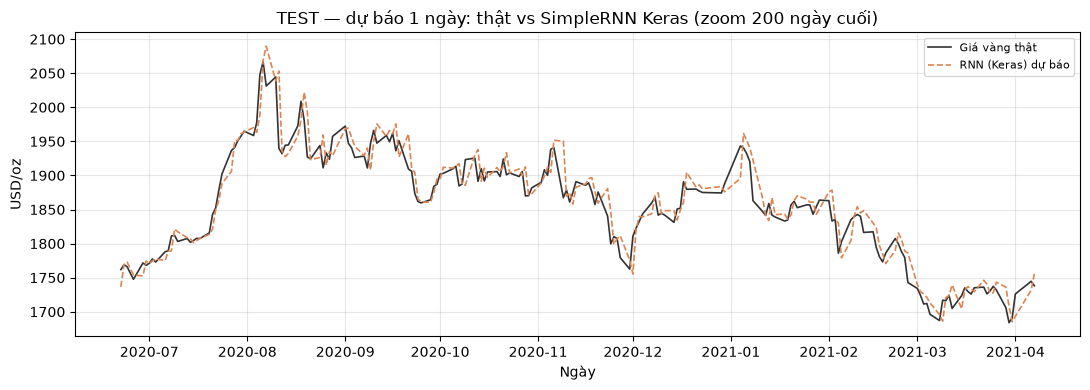

In [16]:
test_dates = test_df.index[L_WINDOW:]
fig, ax = plt.subplots(figsize=(11, 4))
zoom = slice(-200, None)
ax.plot(test_dates[zoom], y_true_real[zoom], color="#333333", lw=1.2, label="Giá vàng thật")
ax.plot(test_dates[zoom], pred_real[zoom], color="#DD8452", lw=1.2, ls="--", label="RNN (Keras) dự báo")
ax.set_ylabel("USD/oz"); ax.set_xlabel("Ngày")
ax.set_title("TEST — dự báo 1 ngày: thật vs SimpleRNN Keras (zoom 200 ngày cuối)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-13-keras-predictions.png", bbox_inches="tight")
plt.show()

 ### §6.2 Dự báo đệ quy 30 ngày — `metals-14-keras-forecast.png`

 **Hàm `recursive_forecast_keras`** — vai trò: **đa bước tự hồi trên Δ** — cửa sổ 30 ngày kết
 thúc trước 30 ngày cuối của test; mỗi bước dự báo Δ̂ (chặn guard ±3σ), **cộng dồn** vào giá
 vàng scaled gần nhất $z_{t+1} = z_t + \hat{\Delta}$, lấp vào cửa sổ rồi lặp 30 lần.
 **Giả định:** giá bạc đóng băng ở mức cuối (mô hình chỉ dự báo vàng) — ghi rõ để đọc đúng ý.
 - **Input:** mảng đặc trưng scaled (n,2), số bước, biên guard — **Output:** giá vàng USD/oz
   30 ngày dự báo.
 - **Lưu ý trung thực:** mỗi bước tự nuôi đầu ra của mình → **lỗi tích luỹ**; guard ±3σ giữ
   đường không bùng nổ nhưng Δ̂ nhỏ dần (mean reversion) → đường dự báo đi ngang, trên đoạn
   test cuối có xu hướng mạnh thì RMSE đệ quy vẫn lớn.

Dự báo đệ quy 30 ngày cuối test: RMSE 212.51 USD | MAPE 11.40%


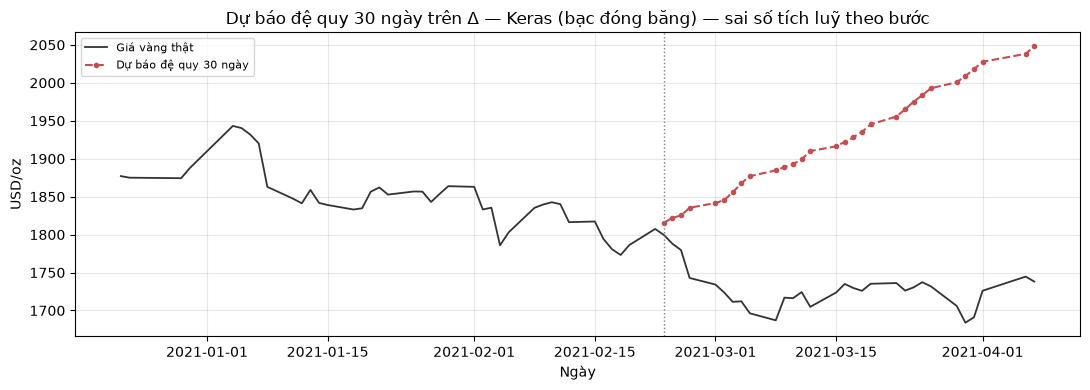

In [17]:
def recursive_forecast_keras(model, features_scaled, L, steps, bound):
    """Đệ quy steps bước trên Δ: z_(t+1) = z_t + clip(Δ̂, ±3σ); bạc đóng băng."""
    start = len(features_scaled) - steps - L
    window = features_scaled[start:start + L].copy()
    silver_frozen = window[-1, 1]
    preds_scaled = []
    for _ in range(steps):
        delta = float(model.predict(window[np.newaxis, ...].astype(np.float32), verbose=0)[0, 0])
        delta = float(np.clip(delta, -bound, bound))          # guard Δ̂ trong ±3σ
        next_gold = window[-1, 0] + delta                     # cộng dồn Δ̂ vào giá scaled
        preds_scaled.append(next_gold)
        window = np.vstack([window[1:], np.array([next_gold, silver_frozen], dtype=np.float32)])
    return inverse_gold(np.array(preds_scaled), scaler)


STEPS = 30
forecast = recursive_forecast_keras(model, test_s, L_WINDOW, STEPS, DELTA_BOUND)
actual_last = gold_test_real[-STEPS:]
fc_metrics = evaluate_forecast(actual_last, forecast)
print("Dự báo đệ quy %d ngày cuối test: RMSE %.2f USD | MAPE %.2f%%"
      % (STEPS, fc_metrics["rmse"], fc_metrics["mape"]))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(test_df.index[-(STEPS + 40):], gold_test_real[-(STEPS + 40):],
        color="#333333", lw=1.3, label="Giá vàng thật")
ax.plot(test_df.index[-STEPS:], forecast, color="#C44E52", lw=1.5, ls="--", marker="o",
        ms=3, label="Dự báo đệ quy %d ngày" % STEPS)
ax.axvline(test_df.index[-STEPS], color="gray", ls=":", lw=1)
ax.set_ylabel("USD/oz"); ax.set_xlabel("Ngày")
ax.set_title("Dự báo đệ quy 30 ngày trên Δ — Keras (bạc đóng băng) — sai số tích luỹ theo bước")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-14-keras-forecast.png", bbox_inches="tight")
plt.show()

 ### §6.3 Scatter thật vs dự báo — `metals-15-keras-scatter.png`
 Điểm nằm sát đường $y=x$ → khớp mặt bằng giá; sai lệch chủ yếu là độ trễ 1 ngày.

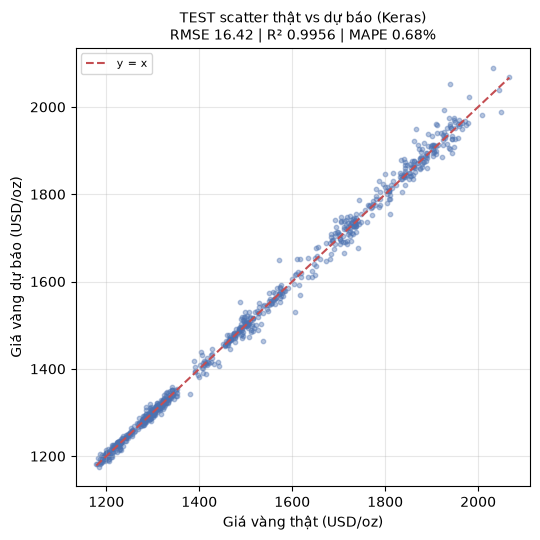

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_true_real, pred_real, s=10, alpha=0.4, color="#4C72B0")
lo, hi = y_true_real.min(), y_true_real.max()
ax.plot([lo, hi], [lo, hi], color="#C44E52", lw=1.5, ls="--", label="y = x")
ax.set_xlabel("Giá vàng thật (USD/oz)"); ax.set_ylabel("Giá vàng dự báo (USD/oz)")
ax.set_title("TEST scatter thật vs dự báo (Keras)\nRMSE %.2f | R² %.4f | MAPE %.2f%%"
             % (m_model["rmse"], m_model["r2"], m_model["mape"]), fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "metals-15-keras-scatter.png", bbox_inches="tight")
plt.show()

 ---
 ## §7. Lưu model + meta JSON

 Lưu model ở **format `.keras`** (native Keras 3): `../model/metals_rnn_keras.keras`; toàn bộ
 cấu hình, chỉ số test (model + naive + đệ quy 30 ngày), lịch sử loss, danh sách figure vào
 `../model/metals_keras_meta.json`.

In [19]:
model_path = MODEL / "metals_rnn_keras.keras"
meta_path = MODEL / "metals_keras_meta.json"
model.save(model_path)

meta = {
    "model": "metals_rnn_keras",
    "framework": "keras (TensorFlow %s)" % tf.__version__,
    "dataset": "Kaggle lbronchal/gold-and-silver-prices-dataset (1968-2021)",
    "config": {"window": L_WINDOW, "hidden": 128, "epochs_max": EPOCHS, "patience": 4,
               "epochs_run": history["epochs_run"], "best_epoch": history["best_epoch"],
               "lr": LR, "batch": BATCH, "split": [n_train, n_val - n_train, n - n_val],
               "scaler": "MinMaxScaler fit trên train", "seed": RANDOM_SEED,
               "params": int(model.count_params()),
               "target": "delta_residual (z[i,0]-z[i-1,0], scaled)",
               "delta_guard": {"rule": "clip nhãn y và dự báo Δ̂ trong ±3σ(Δ train)",
                               "sigma_scaled": round(SIGMA_DELTA, 6),
                               "bound_usd": round(BOUND_USD, 3)}},
    "metrics": {"rmse": m_model["rmse"], "mae": m_model["mae"], "mape": m_model["mape"],
                "r2": m_model["r2"], "directional_acc": d_model,
                "naive": {"rmse": m_naive["rmse"], "mae": m_naive["mae"], "mape": m_naive["mape"],
                          "r2": m_naive["r2"], "directional_acc": d_naive},
                "recursive_30d": fc_metrics,
                "prev_level_metrics": {"rmse": PREV_LEVEL_KS["rmse"], "mape": PREV_LEVEL_KS["mape"],
                                       "note": "bản dự báo mức giá scaled trước nâng cấp (hidden 64)"}},
    "history": {"train_loss": history["train_loss"], "val_loss": history["val_loss"]},
    "model_file": str(model_path),
    "figures": ["metals-10-keras-eda.png", "metals-11-keras-split.png", "metals-12-keras-loss.png",
                "metals-13-keras-predictions.png", "metals-14-keras-forecast.png",
                "metals-15-keras-scatter.png"],
}
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print("Đã lưu:", model_path)
print("Đã lưu:", meta_path)

Đã lưu: ..\model\metals_rnn_keras.keras
Đã lưu: ..\model\metals_keras_meta.json


 ---
 ## Kết luận

 | Bước | Kết quả chính |
 |---|---|
 | EDA rút gọn | Cửa sổ mô hình 2000+ (5.332 ngày) — chi tiết regime change 1971 & 4 hình EDA ở notebook 01 |
 | Preprocess | Chronological 70/15/15, MinMax fit trên train, L=30, [gold, silver] → **nhãn Δ phần dư clip ±3σ** — giống hệt nb 01 |
 | Model | `SimpleRNN(128)` + `Dense(1)`, 16.897 tham số (Keras 1 bias vs PyTorch 2 bias → 17.025) |
 | Train | MSE (trên Δ scaled) + Adam 1e-3, batch 64, EarlyStopping patience 4 + restore best (≤30 epochs) |
 | Test | Bản Δ: PyTorch ~15,4 (thắng nhẹ naive 15,5) / Keras ~16,4 (ngang naive) — so với bản mức giá cũ 33,4 / 82,4 (thua nặng); DirAcc 52-53% > 50% |

 **Thông điệp trung thực:** hai framework cùng dữ liệu, cùng seed, cùng cấu hình Δ cho kết quả
 tương đương và sau nâng cấp **đã về tới mức ngang/vượt baseline naive** (trước đó thua nặng
 2-5 lần) — phần lớn công lao thuộc về việc đổi mục tiêu dự báo từ mức giá sang phần dư Δ,
 không phải ở framework. Lợi thế so naive vẫn mỏng; giá trị của notebook là quy trình RNN
 chuẩn (cửa sổ trượt, chia chronological, inverse scale, đối chiếu baseline) chứ không phải
 "máy in tiền".

 **Hướng phát triển (nếu tiếp tục):**
 1. Dự báo trên **lợi suất %** thay vì Δ tuyệt đối (chuẩn hoá theo mặt bằng giá);
 2. Thêm đặc trưng (tương quan trượt 60 ngày, ngày trong tuần, USD-index);
 3. Nâng cấp LSTM/GRU (quên có chọn lọc) và so với baseline naive + ARIMA;
 4. Đánh giá bằng backtest có chi phí giao dịch thay vì chỉ RMSE/DirAcc.

In [20]:
print("Tổng kết (Keras, bản Δ residual): epochs chạy %d | best epoch %d | RMSE %.2f (naive %.2f) | MAPE %.3f%% | DirAcc %.2f%% (naive quán tính %.2f%%) | bản mức giá cũ RMSE %.2f"
      % (history["epochs_run"], history["best_epoch"], m_model["rmse"], m_naive["rmse"],
         m_model["mape"], d_model, d_naive, PREV_LEVEL_KS["rmse"]))

Tổng kết (Keras, bản Δ residual): epochs chạy 20 | best epoch 16 | RMSE 16.42 (naive 15.48) | MAPE 0.678% | DirAcc 51.76% (naive quán tính 51.30%) | bản mức giá cũ RMSE 82.38
